In [2]:
import pandas as pd 
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [3]:
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)
data["Species"] = iris.target

In [4]:
X = data.drop("Species", axis=1)
y = data["Species"]

In [5]:
# Encode and split the Datasets
encode = LabelEncoder()
y = encode.fit_transform(y)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [7]:
gnb_model = GaussianNB()
gnb_model.fit(X_train,y_train)

GaussianNB()

In [8]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.stats import norm 

In [9]:
feature_names = iris.feature_names
num_features = len(feature_names)
num_classes = len(np.unique(y))

In [10]:
X_np = X.to_numpy()

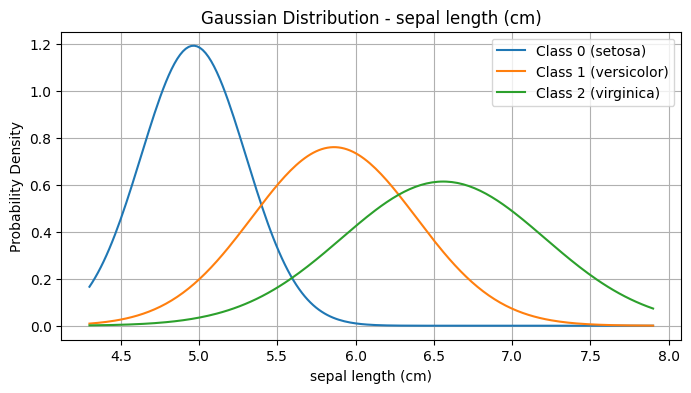

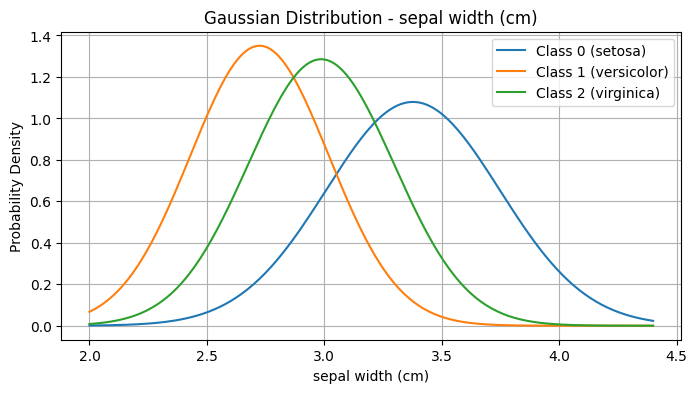

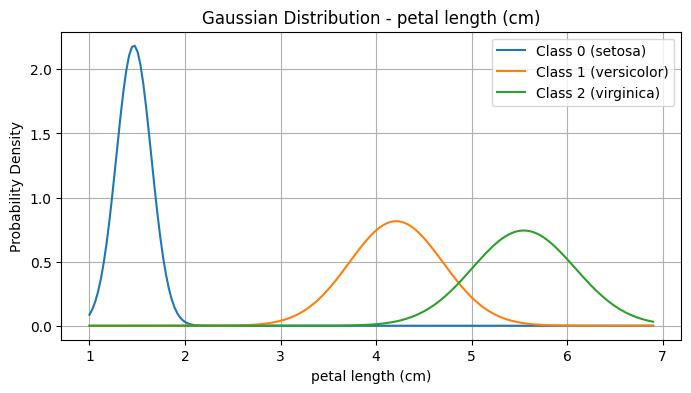

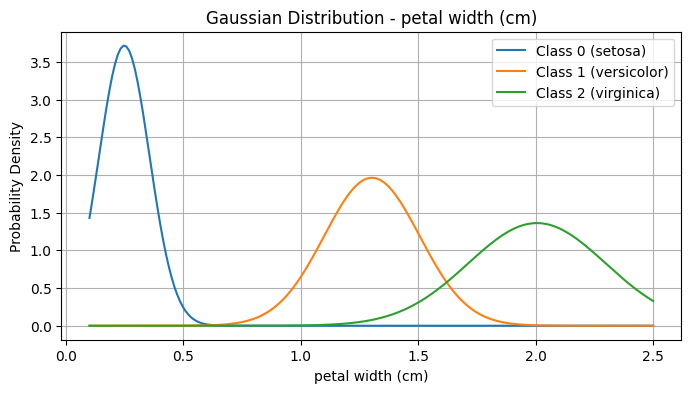

In [14]:
for feature_index in range(num_features):
    feature_name = feature_names[feature_index]
    x_vals = np.linspace(X_np[:, feature_index].min(), X_np[:,feature_index].max(),200)

    plt.figure(figsize=(8,4))

    for cls in range(num_classes):
        mean = gnb_model.theta_[cls, feature_index]
        std = np.sqrt(gnb_model.var_[cls, feature_index])

        y_vals = norm.pdf(x_vals, mean, std)
        plt.plot(x_vals, y_vals, label=f"Class {cls} ({iris.target_names[cls]})")
    
    plt.title(f"Gaussian Distribution - {feature_name}")
    plt.xlabel(feature_name)
    plt.ylabel("Probability Density")
    plt.legend()
    plt.savefig(f"figures/{feature_name}")
    plt.grid(True)

    plt.show()